# 03 — Round-2 challenge benchmark

**Scope of this notebook: harder synthetic faults, and an honest re-test of the *unchanged* detector.**

Nothing about the model is touched here. The Isolation Forest, its 16 stationary features, the
adaptive rolling-quantile threshold and the flat-run rule are loaded frozen from `models/` exactly
as `notebooks/02` exported them. No refitting, no threshold tuning, no feature changes.

## What this notebook does

| | |
|---|---|
| **A. Baseline set** | The Round-1 five-class injector, ported verbatim into `src/fault_injection.py` as `legacy_inject`. It reproduces the original 27 episodes / 179 faulty rows **bit for bit**, so the published Round-1 result stays intact and comparable. |
| **B. Challenge set** | Eight fault models including transients, accelerating drift, ramped bias, intermittency and two combined faults. Magnitudes are relative to each variable's **local** variability, not one shared absolute number. |

Both sets are scored with the same frozen detector, and the two are compared.

## The honest question

> Does the detector generalise beyond the simple, large-magnitude faults it was originally tested on?

The rule for this step: **do not tune anything to the challenge set.** Making the test harder only
means something if the detector is not adjusted to pass it.

## What these faults are NOT

They are a *simulation*. There is no field-labelled record of real sensor failures at this station —
that absence is the reason synthetic injection exists at all. The challenge set is a more plausible
stress test, **not** evidence of real-world performance, and no number here should be presented as one.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
from fault_injection import (FaultSimulator, legacy_inject, CHALLENGE_CONFIG,
                             VARS, SEVERITY, FAULT_KINDS)
from inference import WeatherFaultDetector
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
SEED = 42
SPLIT_FRAC = 0.70

print("fault kinds available:", FAULT_KINDS)
print("severity presets     :", SEVERITY)

fault kinds available: ['spike', 'drift', 'bias', 'stuck_at', 'noise_burst', 'intermittent_spikes', 'drift_plus_noise', 'bias_plus_spikes']
severity presets     : {'mild': 0.6, 'moderate': 1.0, 'severe': 1.6}


## 1. Clean data

Same preparation as notebook 02 Stage 1: drop the constant/collinear columns and fill the handful of
holes by time interpolation. Nothing else — the faults are injected onto this baseline.

In [2]:
raw = pd.read_csv("../data/processed/vidd_2023_clean.csv", parse_dates=["time"])
df = raw.drop(columns=["station", "dew_c", "dew_qc"]).sort_values("time").reset_index(drop=True)
df[VARS] = (df.set_index("time")[VARS]
              .interpolate(method="time", limit=2, limit_direction="both").to_numpy())

n = len(df)
SPLIT = int(SPLIT_FRAC * n)
clean = {v: df[v].to_numpy(copy=True) for v in VARS}

print(f"clean frame: {df.shape}, NaNs in modelled vars: {int(df[VARS].isna().sum().sum())}")
print(f"chronological split at index {SPLIT} -> {df['time'].iloc[SPLIT]}")
print(f"local robust sigma per variable (drives all fault magnitudes):")
for v in VARS:
    from fault_injection import _robust_scale
    print(f"   {v:9s} {_robust_scale(clean[v]):8.3f}")

clean frame: (2861, 10), NaNs in modelled vars: 0
chronological split at index 2002 -> 2023-09-11 09:00:00
local robust sigma per variable (drives all fault magnitudes):
   temp_c       8.303
   slp_hpa      9.637
   rh_pct      24.604


## 2. Inject both benchmarks

`legacy_inject` is frozen on purpose — its value is that it does not change. The assertion below is
the guarantee that the Round-1 headline is still the same experiment.

In [3]:
base_faulty, base_labels, base_eps = legacy_inject(df, seed=SEED)

assert len(base_eps) == 27 and int(base_labels.is_fault.sum()) == 179, \
    "legacy injector drifted from the Round-1 benchmark"
print(f"A. BASELINE  : {len(base_eps):3d} episodes, {int(base_labels.is_fault.sum()):4d} faulty rows "
      f"({base_labels.is_fault.mean():.2%} contamination)  [matches Round-1 exactly]")

sim = FaultSimulator(df, seed=SEED, severity="moderate")
chal_faulty, chal_labels, chal_eps = sim.inject(CHALLENGE_CONFIG)
print(f"B. CHALLENGE : {len(chal_eps):3d} episodes, {int(chal_labels.is_fault.sum()):4d} faulty rows "
      f"({chal_labels.is_fault.mean():.2%} contamination)")

print("\nchallenge episode mix:")
print(chal_eps.groupby("fault_type")
      .agg(episodes=("episode_id", "size"), rows=("n_modified", "sum"),
           median_window=("window_obs", "median"))
      .to_string())

A. BASELINE  :  27 episodes,  179 faulty rows (6.26% contamination)  [matches Round-1 exactly]
B. CHALLENGE :  60 episodes,  395 faulty rows (13.81% contamination)

challenge episode mix:
                     episodes  rows  median_window
fault_type                                        
bias                        6    62           11.0
bias_plus_spikes            3    40           14.0
drift                       6    84           14.5
drift_plus_noise            3    38           12.0
intermittent_spikes         6    20           15.0
noise_burst                 6    56            9.5
spike                      24    33            1.0
stuck_at                    6    62           11.5


### Fault magnitudes are per-variable, by construction

The single most important change from Round 1. Temperature, pressure and humidity live on completely
different scales, so a fixed "+5" means three different things. Every magnitude in the challenge set
is a multiple of the variable's **local** standard deviation in a window around the episode.

A side effect worth stating: in a calm stretch, "4 sigma" is a much *smaller* absolute jump than the
fixed magnitudes Round 1 used. That is deliberate — it is a large part of what makes the set harder.

In [4]:
print("median local sigma actually used, by variable:")
print(chal_eps.groupby("variable")["local_sigma"].median().round(3).to_string())
print("\nsample of injected episodes:")
print(chal_eps[["episode_id", "fault_type", "variable", "window_obs",
                "n_modified", "local_sigma", "detail"]].head(12).to_string(index=False))

median local sigma actually used, by variable:
variable
rh_pct     17.730
slp_hpa     2.409
temp_c      4.780

sample of injected episodes:
 episode_id fault_type variable  window_obs  n_modified  local_sigma                                 detail
          0      spike   temp_c           1           1       4.5566 +19.67 single point (4.3x local sigma)
          1      spike   temp_c           1           1       4.7762 +26.63 single point (5.6x local sigma)
          2      spike   temp_c           1           1       4.7831 +15.70 single point (3.3x local sigma)
          3      spike  slp_hpa           1           1       2.4092 +14.28 single point (5.9x local sigma)
          4      spike  slp_hpa           1           1       2.4092 +12.91 single point (5.4x local sigma)
          5      spike  slp_hpa           1           1       2.4092  +8.15 single point (3.4x local sigma)
          6      spike   rh_pct           1           1      21.3683 +87.87 single point (4.1x local sig

## 3. What each fault looks like

One representative episode per class: healthy region, onset, fault behaviour, recovery. Grey is the
clean signal, red is what the detector receives, the shaded band is the labelled episode.

Read these before trusting any metric — if a fault is invisible here it will be invisible to the model.

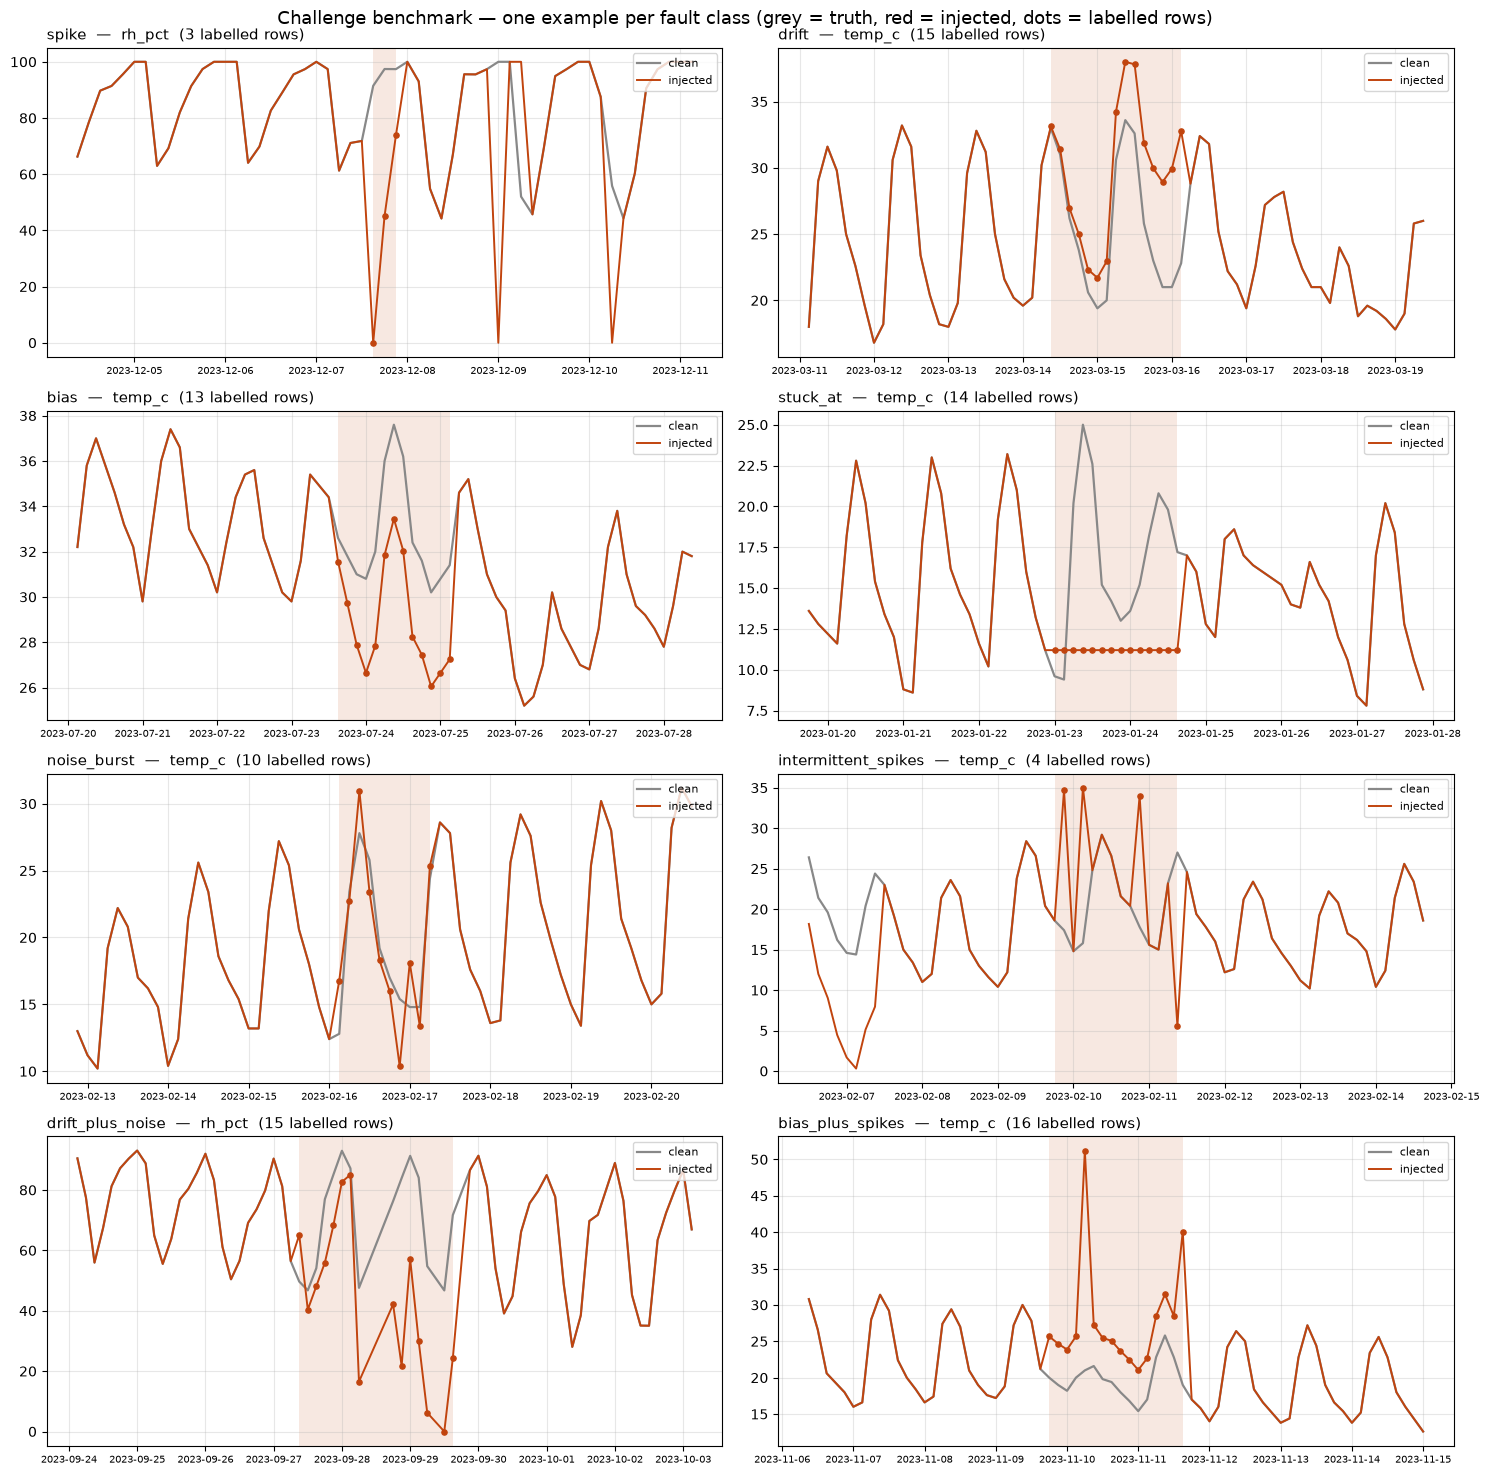

In [5]:
ORDER = ["spike", "drift", "bias", "stuck_at", "noise_burst",
         "intermittent_spikes", "drift_plus_noise", "bias_plus_spikes"]
PAD = 26

def pick(kind, prefer_long=True):
    sub = chal_eps[chal_eps.fault_type == kind]
    if sub.empty: return None
    return sub.sort_values("n_modified", ascending=not prefer_long).iloc[0]

fig, axes = plt.subplots(4, 2, figsize=(15, 15))
for ax, kind in zip(axes.ravel(), ORDER):
    ep = pick(kind)
    if ep is None:
        ax.axis("off"); continue
    v = ep["variable"]
    lo = max(0, ep["start_idx"] - PAD); hi = min(n, ep["end_idx"] + PAD + 1)
    t = df["time"].iloc[lo:hi]
    ax.plot(t, clean[v][lo:hi], lw=1.6, color="#888", label="clean")
    ax.plot(t, chal_faulty[v].to_numpy()[lo:hi], lw=1.4, color="#c1440e", label="injected")
    ax.axvspan(df["time"].iloc[ep["start_idx"]], df["time"].iloc[ep["end_idx"]],
               color="#c1440e", alpha=0.12, lw=0)
    # mark the rows that are actually labelled faulty (matters for intermittent)
    m = ((chal_labels.episode_id == ep["episode_id"]) & (chal_labels.is_fault == 1)).to_numpy()
    mi = np.flatnonzero(m)
    ax.scatter(df["time"].iloc[mi], chal_faulty[v].to_numpy()[mi], s=14, color="#c1440e", zorder=5)
    ax.set_title(f"{kind}  —  {v}  ({ep['n_modified']} labelled rows)", fontsize=10.5, loc="left")
    ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(axis="x", labelsize=7)

fig.suptitle("Challenge benchmark — one example per fault class "
             "(grey = truth, red = injected, dots = labelled rows)", fontsize=13)
fig.tight_layout(); plt.show()

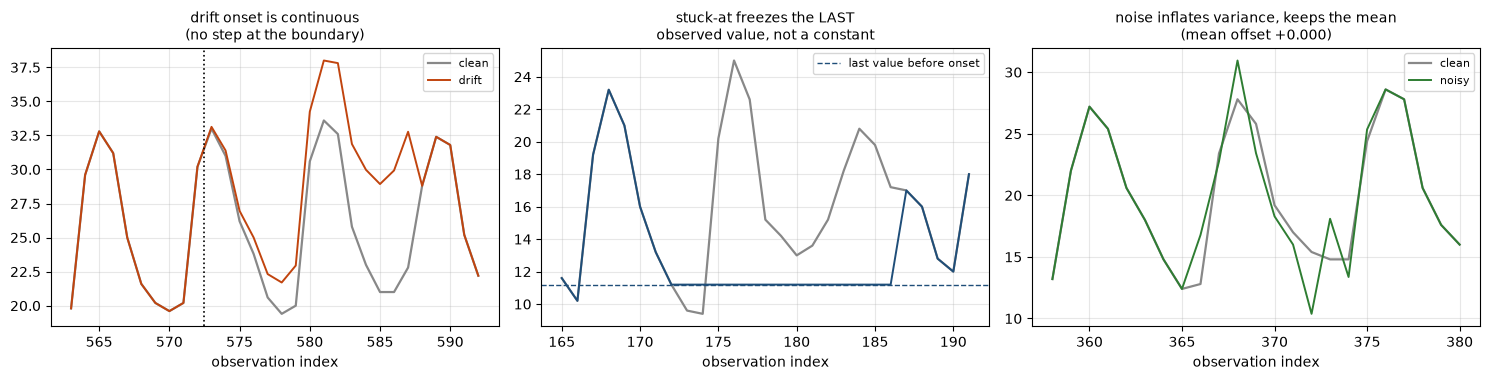

In [6]:
# Zoom on the three properties that are easiest to get wrong.
fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))

ep = pick("drift")
v = ep["variable"]; lo = ep["start_idx"] - 10; hi = ep["end_idx"] + 6
axes[0].plot(range(lo, hi), clean[v][lo:hi], lw=1.6, color="#888", label="clean")
axes[0].plot(range(lo, hi), chal_faulty[v].to_numpy()[lo:hi], lw=1.4, color="#c1440e", label="drift")
axes[0].axvline(ep["start_idx"] - 0.5, color="k", ls=":", lw=1.2)
axes[0].set_title("drift onset is continuous\n(no step at the boundary)", fontsize=10)

ep = pick("stuck_at")
v = ep["variable"]; lo = ep["start_idx"] - 8; hi = ep["end_idx"] + 6
axes[1].plot(range(lo, hi), clean[v][lo:hi], lw=1.6, color="#888")
axes[1].plot(range(lo, hi), chal_faulty[v].to_numpy()[lo:hi], lw=1.4, color="#1f4e79")
axes[1].axhline(clean[v][ep["start_idx"] - 1], color="#1f4e79", ls="--", lw=1,
                label="last value before onset")
axes[1].set_title("stuck-at freezes the LAST\nobserved value, not a constant", fontsize=10)

ep = pick("noise_burst")
v = ep["variable"]; lo = ep["start_idx"] - 8; hi = ep["end_idx"] + 6
axes[2].plot(range(lo, hi), clean[v][lo:hi], lw=1.6, color="#888", label="clean")
axes[2].plot(range(lo, hi), chal_faulty[v].to_numpy()[lo:hi], lw=1.4, color="#2e7d32", label="noisy")
off = chal_faulty[v].to_numpy()[ep["start_idx"]:ep["end_idx"]+1] - clean[v][ep["start_idx"]:ep["end_idx"]+1]
axes[2].set_title(f"noise inflates variance, keeps the mean\n(mean offset {off.mean():+.3f})", fontsize=10)

for a in axes: a.grid(alpha=0.3); a.legend(fontsize=8); a.set_xlabel("observation index")
fig.tight_layout(); plt.show()

## 4. The frozen detector

Loaded from `models/` and used exactly as Stage 6 defined it: Isolation Forest on the 16 stationary
features, adaptive trailing 30-day quantile threshold, OR the flat-run rule. `run_detector` below is
the same code path `src/inference.py` serves over HTTP.

In [7]:
det = WeatherFaultDetector.load("../models")
print(f"loaded: {det.model.n_estimators} trees, random_state={det.model.random_state}, "
      f"{len(det.features)} features")
print(f"threshold: {det.manifest['threshold']['mode']} "
      f"window={det.manifest['threshold']['window']} q={det.threshold_q:.6f}")


def run_detector(frame):
    """Stage-6 hybrid detector. No refitting, no tuning."""
    feats = det._build_features(frame[["time"] + VARS].copy())
    X = feats[det.features]
    score = -det.model.score_samples(X)
    thr = det._adaptive_threshold(feats["time"], score)
    if_pred = (score > thr).astype(int)
    flat, _ = det._flat_run_flags(feats)
    flat = flat.astype(int)
    return dict(score=score, thr=thr, if_pred=if_pred, flat_pred=flat,
                pred=((if_pred + flat) > 0).astype(int))


base_res = run_detector(base_faulty)
chal_res = run_detector(chal_faulty)
print("\nsanity: detector reproduces the Round-1 test-split headline?")
y = base_labels.is_fault.to_numpy()
p, r, f, _ = precision_recall_fscore_support(y[SPLIT:], base_res["pred"][SPLIT:],
                                             average="binary", zero_division=0)
print(f"   precision {p:.4f}  recall {r:.4f}  F1 {f:.4f}   (published: 0.2588 / 0.4074 / 0.3165)")
assert abs(p - 0.2588) < 5e-4 and abs(f - 0.3165) < 5e-4, "detector path diverged from Stage 6"
print("   EXACT MATCH - the comparison below is like-for-like.")

loaded: 200 trees, random_state=42, 16 features
threshold: adaptive_rolling_quantile window=30D q=0.937562

sanity: detector reproduces the Round-1 test-split headline?
   precision 0.2588  recall 0.4074  F1 0.3165   (published: 0.2588 / 0.4074 / 0.3165)
   EXACT MATCH - the comparison below is like-for-like.


## 5. Metrics

Three things worth stating before the numbers.

**Precision depends on the base rate.** The challenge set carries more contamination than the
baseline (longer, more numerous episodes). A detector flagging rows at random scores precision equal
to the contamination rate, so raw precision is *not* comparable across the two sets. `lift_over_random`
= precision / contamination is reported alongside, and that one is comparable.

**Episode recall has a chance floor.** At a ~9 % alert rate, a 12-observation episode has a ~68 %
chance of containing a flagged row by luck alone. The chance-level baseline is computed and reported
so "episode recall 1.00" is not mistaken for 1.00 worth of skill.

**Detection delay is positional, not latency.** The detector is offline/batch — its 24 h rolling
window is centred and the flat-run rule reads forward — so this is "how far into the episode the
first flag lands", not how long a live system would take to alarm. Reported in observations and hours
(3 h cadence), with that limitation stated rather than hidden.

In [8]:
def row_metrics(y, pred):
    p, r, f, _ = precision_recall_fscore_support(y, pred, average="binary",
                                                 pos_label=1, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    base = float(y.mean())
    return dict(n_rows=len(y), n_faulty=int(y.sum()), contamination=base,
                precision=p, recall=r, f1=f, tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn),
                n_flagged=int(pred.sum()), alert_rate=float(pred.mean()),
                lift_over_random=(p / base if base else np.nan))


def episode_table(labels, episodes, pred, lo=None, hi=None):
    """One row per episode. Detected = at least one MODIFIED row flagged."""
    ep_id = labels.episode_id.to_numpy(); isf = labels.is_fault.to_numpy()
    out = []
    for e in episodes.itertuples():
        if lo is not None and not (e.start_idx >= lo and e.end_idx < hi):
            continue
        idx = np.flatnonzero((ep_id == e.episode_id) & (isf == 1))
        if idx.size == 0:
            continue
        hit = idx[pred[idx] == 1]
        out.append(dict(episode_id=e.episode_id, fault_type=e.fault_type, variable=e.variable,
                        n_modified=int(idx.size), detected=bool(hit.size),
                        delay_obs=int(hit.min() - idx.min()) if hit.size else np.nan))
    return pd.DataFrame(out)


def chance_recall(ep_df, alert_rate):
    """Episode recall a RANDOM detector would reach at the same alert rate."""
    if ep_df.empty: return np.nan
    return float(np.mean(1.0 - (1.0 - alert_rate) ** ep_df.n_modified.to_numpy()))


def per_class(ep_df, alert_rate):
    if ep_df.empty: return pd.DataFrame()
    g = ep_df.groupby("fault_type").agg(episodes=("detected", "size"),
                                        detected=("detected", "sum"),
                                        rows=("n_modified", "sum"),
                                        median_delay_obs=("delay_obs", "median"))
    g["episode_recall"] = (g.detected / g.episodes).round(3)
    g["chance"] = [round(chance_recall(ep_df[ep_df.fault_type == k], alert_rate), 3) for k in g.index]
    g["skill_vs_chance"] = (g.episode_recall - g.chance).round(3)
    g["median_delay_h"] = g.median_delay_obs * 3
    return g[["episodes", "detected", "episode_recall", "chance", "skill_vs_chance",
              "rows", "median_delay_obs", "median_delay_h"]]

### 5.1 Headline comparison

The **test split** is the honest primary: the model was fit on the first 70 % of the *baseline*
series, so those rows are in-sample for the baseline set. Neither set's faults appear in the test
region during training.

The full series is also shown — for the challenge set it is entirely fair (the model never saw a
single challenge fault anywhere), which is why it carries the larger episode counts used for the
per-class table.

In [9]:
rows = []
for name, labels, eps, res in [("A. baseline (Round-1)", base_labels, base_eps, base_res),
                               ("B. challenge (Round-2)", chal_labels, chal_eps, chal_res)]:
    y = labels.is_fault.to_numpy()
    for scope, sl, lo, hi in [("test split", slice(SPLIT, n), SPLIT, n),
                              ("full series", slice(0, n), None, None)]:
        m = row_metrics(y[sl], res["pred"][sl])
        ep = episode_table(labels, eps, res["pred"], lo, hi)
        m.update(benchmark=name, scope=scope, episodes=len(ep),
                 episode_recall=round(ep.detected.mean(), 3) if len(ep) else np.nan,
                 chance_episode_recall=round(chance_recall(ep, m["alert_rate"]), 3),
                 median_delay_obs=float(ep.delay_obs.median()) if len(ep) else np.nan)
        rows.append(m)

summary = pd.DataFrame(rows).set_index(["benchmark", "scope"])
summary["skill_vs_chance"] = (summary.episode_recall - summary.chance_episode_recall).round(3)

cols = ["episodes", "n_faulty", "contamination", "precision", "recall", "f1",
        "alert_rate", "lift_over_random", "episode_recall", "chance_episode_recall",
        "skill_vs_chance", "median_delay_obs"]
print("HEADLINE COMPARISON\n")
print(summary[cols].round(4).to_string())

HEADLINE COMPARISON

                                    episodes  n_faulty  contamination  precision  recall      f1  alert_rate  lift_over_random  episode_recall  chance_episode_recall  skill_vs_chance  median_delay_obs
benchmark              scope                                                                                                                                                                            
A. baseline (Round-1)  test split          7        54         0.0629     0.2588  0.4074  0.3165      0.0990            4.1172           1.000                  0.448            0.552               0.0
                       full series        27       179         0.0626     0.3673  0.5028  0.4245      0.0856            5.8714           0.889                  0.358            0.531               0.0
B. challenge (Round-2) test split         22       125         0.1455     0.6579  0.4000  0.4975      0.0885            4.5211           1.000                  0.347          

### 5.2 Per-fault-class episode recall

Computed on the **full series** so each class has usable support (the test split leaves 1–3 episodes
per class, too thin to read). For the challenge set the full series is a fair evaluation — none of
these faults existed when the model was fitted.

`skill_vs_chance` is the column that matters. A class sitting at or below 0 is not being detected;
it is being hit by the detector's background alarm rate.

In [10]:
for name, labels, eps, res in [("A. BASELINE (Round-1)", base_labels, base_eps, base_res),
                               ("B. CHALLENGE (Round-2)", chal_labels, chal_eps, chal_res)]:
    ar = float(res["pred"].mean())
    ep = episode_table(labels, eps, res["pred"])
    print("=" * 108)
    print(f"### {name} - full series, alert rate {ar:.1%}")
    print(per_class(ep, ar).to_string())
    print(f"   overall episode recall {ep.detected.mean():.3f} "
          f"({int(ep.detected.sum())}/{len(ep)}), chance {chance_recall(ep, ar):.3f}")
    miss = ep[~ep.detected]
    if len(miss):
        print("   MISSED:")
        print(miss[["episode_id", "fault_type", "variable", "n_modified"]].to_string(index=False))
    print()

### A. BASELINE (Round-1) - full series, alert rate 8.6%
             episodes  detected  episode_recall  chance  skill_vs_chance  rows  median_delay_obs  median_delay_h
fault_type                                                                                                      
bias                3         3           1.000   0.655            0.345    36               4.0            12.0
drift               3         3           1.000   0.776            0.224    51               3.0             9.0
noise_burst         3         2           0.667   0.648            0.019    35               2.5             7.5
spike              15        13           0.867   0.086            0.781    15               0.0             0.0
stuck_at            3         3           1.000   0.714            0.286    42               0.0             0.0
   overall episode recall 0.889 (24/27), chance 0.358
   MISSED:
 episode_id  fault_type variable  n_modified
         10       spike   rh_pct          

### 5.3 Which detector component fired?

Isolation Forest and the flat-run rule are complementary by design. Splitting the credit shows
whether the challenge set shifted the load between them.

In [11]:
rows = []
for name, labels, eps, res in [("baseline", base_labels, base_eps, base_res),
                               ("challenge", chal_labels, chal_eps, chal_res)]:
    ep_id = labels.episode_id.to_numpy(); isf = labels.is_fault.to_numpy()
    for e in eps.itertuples():
        idx = np.flatnonzero((ep_id == e.episode_id) & (isf == 1))
        rows.append(dict(benchmark=name, fault_type=e.fault_type,
                         by_if=bool(res["if_pred"][idx].any()),
                         by_flat=bool(res["flat_pred"][idx].any())))
attr = pd.DataFrame(rows)
tab = attr.groupby(["benchmark", "fault_type"]).agg(
    episodes=("by_if", "size"), caught_by_IF=("by_if", "sum"), caught_by_flat_rule=("by_flat", "sum"))
print("episodes caught by each component (an episode can appear in both)\n")
print(tab.to_string())

episodes caught by each component (an episode can appear in both)

                               episodes  caught_by_IF  caught_by_flat_rule
benchmark fault_type                                                      
baseline  bias                        3             3                    0
          drift                       3             3                    0
          noise_burst                 3             2                    0
          spike                      15            13                    0
          stuck_at                    3             2                    3
challenge bias                        6             2                    1
          bias_plus_spikes            3             3                    0
          drift                       6             6                    0
          drift_plus_noise            3             3                    0
          intermittent_spikes         6             6                    0
          noise_burst            

## 6. Score behaviour on the challenge set

Anomaly score against the adaptive threshold, with challenge episodes shaded. Bands sitting below the
line are the misses.

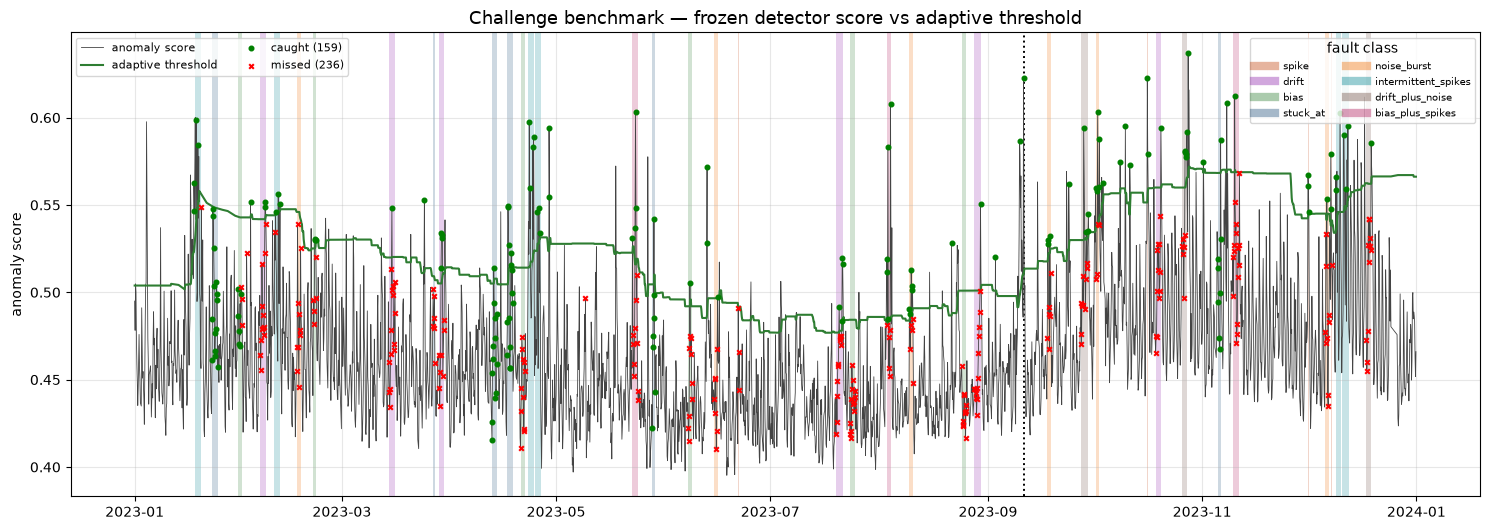

In [12]:
fig, ax = plt.subplots(figsize=(15, 5.4))
ax.plot(df.time, chal_res["score"], lw=0.6, color="#444", zorder=3, label="anomaly score")
ax.plot(df.time, chal_res["thr"], lw=1.5, color="#2e7d32", zorder=4, label="adaptive threshold")
ax.axvline(df.time.iloc[SPLIT], color="k", ls=":", lw=1.4)
COL = {"spike": "#c1440e", "drift": "#8e24aa", "bias": "#2e7d32", "stuck_at": "#1f4e79",
       "noise_burst": "#ef6c00", "intermittent_spikes": "#00838f",
       "drift_plus_noise": "#6d4c41", "bias_plus_spikes": "#ad1457"}
for e in chal_eps.itertuples():
    ax.axvspan(df.time.iloc[e.start_idx], df.time.iloc[e.end_idx],
               color=COL[e.fault_type], alpha=0.22, lw=0, zorder=1)
lab = chal_labels.is_fault.to_numpy().astype(bool)
hit = lab & (chal_res["pred"] == 1); miss = lab & (chal_res["pred"] == 0)
ax.scatter(df.time[hit], chal_res["score"][hit], s=11, c="green", zorder=5, label=f"caught ({hit.sum()})")
ax.scatter(df.time[miss], chal_res["score"][miss], s=11, c="red", marker="x", zorder=5,
           label=f"missed ({miss.sum()})")
first = ax.legend(loc="upper left", fontsize=8, ncol=2); ax.add_artist(first)
ax.legend(handles=[plt.Line2D([], [], color=c, lw=6, alpha=0.4, label=k) for k, c in COL.items()],
          loc="upper right", fontsize=7.5, ncol=2, title="fault class")
ax.set_title("Challenge benchmark — frozen detector score vs adaptive threshold", fontsize=13)
ax.set_ylabel("anomaly score"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 7. Save results

In [13]:
OUT = "../data/processed"
summary.reset_index().to_csv(f"{OUT}/round2_benchmark_comparison.csv", index=False)

pc_all = []
for name, labels, eps, res in [("baseline", base_labels, base_eps, base_res),
                               ("challenge", chal_labels, chal_eps, chal_res)]:
    ar = float(res["pred"].mean())
    t = per_class(episode_table(labels, eps, res["pred"]), ar).reset_index()
    t.insert(0, "benchmark", name); pc_all.append(t)
pd.concat(pc_all).to_csv(f"{OUT}/round2_per_class_episode_recall.csv", index=False)

chal_eps.to_csv(f"{OUT}/round2_challenge_episodes.csv", index=False)
ep_full = episode_table(chal_labels, chal_eps, chal_res["pred"])
ep_full.to_csv(f"{OUT}/round2_challenge_episode_detection.csv", index=False)

for f in ["round2_benchmark_comparison.csv", "round2_per_class_episode_recall.csv",
          "round2_challenge_episodes.csv", "round2_challenge_episode_detection.csv"]:
    print(f"  saved {f}  ({os.path.getsize(f'{OUT}/{f}'):,} bytes)")
print("\nNo existing result file was overwritten; all four names are new.")

  saved round2_benchmark_comparison.csv  (979 bytes)
  saved round2_per_class_episode_recall.csv  (788 bytes)
  saved round2_challenge_episodes.csv  (9,147 bytes)
  saved round2_challenge_episode_detection.csv  (1,899 bytes)

No existing result file was overwritten; all four names are new.


## 8. Diagnosing the two failures

The per-class table shows `bias` at 0.500 (below its chance floor) and one missed `stuck_at`. Before
writing either up, the obvious explanations are tested rather than assumed — both turned out to be
wrong on first guess.

In [14]:
from inference import FLAT_RUN_MIN_LEN
eid = chal_labels.episode_id.to_numpy(); isf = chal_labels.is_fault.to_numpy()
rows_of = lambda x: np.flatnonzero((eid == x) & (isf == 1))

print(f"flat-run rule minimum = {FLAT_RUN_MIN_LEN} identical consecutive readings")
print()
print("A. stuck_at - is a short freeze automatically missed?")
for r in chal_eps[chal_eps.fault_type == "stuck_at"].itertuples():
    i = rows_of(r.episode_id)
    vals = chal_faulty[r.variable].to_numpy()
    lo = r.start_idx
    while lo > 0 and vals[lo - 1] == vals[r.start_idx]:
        lo -= 1
    hi = r.end_idx
    while hi + 1 < n and vals[hi + 1] == vals[r.start_idx]:
        hi += 1
    print(f"   ep{r.episode_id:3d} {r.variable:8s} episode={r.n_modified:3d} obs, "
          f"identical-run in data={hi - lo + 1:3d}  "
          f"flat_fired={str(bool(chal_res['flat_pred'][i].any())):5s} "
          f"detected={bool(chal_res['pred'][i].any())}")
print("   -> NOT a clean length rule. A freeze is EXTENDED when neighbouring real readings happen")
print("      to equal the frozen value. temp_c is stored to 0.1 C so ties are common; rh_pct is")
print("      derived to many decimals so ties essentially never happen - which is why the short")
print("      RH freeze is the one that fell under the minimum.")
print()
print("B. bias - does the offset size explain which episodes are caught?")
bi = chal_eps[chal_eps.fault_type == "bias"].copy()
bi["detected"] = [bool(chal_res["pred"][rows_of(r.episode_id)].any()) for r in bi.itertuples()]
bi["x_sigma"] = [float(r.detail.split("(")[1].split("x")[0]) for r in bi.itertuples()]
bi["onset"] = ["ramp" if "ramped" in r.detail else "step" for r in bi.itertuples()]
print(bi[["episode_id", "variable", "n_modified", "x_sigma", "onset", "detected"]].to_string(index=False))
corr = np.corrcoef(bi.x_sigma, bi.detected.astype(float))[0, 1]
print(f"   corr(offset size, detected) = {corr:+.3f}")
print(f"   detected mean {bi[bi.detected].x_sigma.mean():.2f}x sigma vs "
      f"missed mean {bi[~bi.detected].x_sigma.mean():.2f}x sigma")
print(f"   by variable: {bi.groupby('variable').detected.mean().round(2).to_dict()}")
print(f"   by onset   : {bi.groupby('onset').detected.mean().round(2).to_dict()}")
print("   -> magnitude does NOT explain it: the MISSED biases are on average slightly LARGER.")

flat-run rule minimum = 8 identical consecutive readings

A. stuck_at - is a short freeze automatically missed?
   ep 36 temp_c   episode=  7 obs, identical-run in data=  8  flat_fired=True  detected=True
   ep 37 slp_hpa  episode=  8 obs, identical-run in data= 10  flat_fired=True  detected=True
   ep 38 rh_pct   episode=  6 obs, identical-run in data=  7  flat_fired=False detected=False
   ep 39 temp_c   episode= 14 obs, identical-run in data= 15  flat_fired=True  detected=True
   ep 40 slp_hpa  episode= 13 obs, identical-run in data= 15  flat_fired=True  detected=True
   ep 41 rh_pct   episode= 14 obs, identical-run in data= 15  flat_fired=True  detected=True
   -> NOT a clean length rule. A freeze is EXTENDED when neighbouring real readings happen
      to equal the frozen value. temp_c is stored to 0.1 C so ties are common; rh_pct is
      derived to many decimals so ties essentially never happen - which is why the short
      RH freeze is the one that fell under the minimum.

B. 

## 9. What the challenge set exposed

Written after reading the tables, and after two first guesses turned out to be wrong.

### The detector does partly generalise

Overall episode recall barely moves (0.889 -> 0.867 full-series; 1.00 on the test split), and it stays
well clear of the chance floor, so this is skill rather than the background alarm rate. Spikes,
intermittent spikes, drift and both combined faults are caught reliably. Two of the harder new
classes — `intermittent_spikes` (skill +0.72) and `drift_plus_noise` (+0.29) — were caught on the
first attempt with no tuning.

Row-level F1 *rises* (0.317 -> 0.498 on the test split), but that is mostly the base rate: the
challenge set carries 14.6 % contamination against the baseline's 6.3 %. On the base-rate-normalised
measure the two are near-identical (**lift over random 4.12x vs 4.52x**). The correct summary is
"about the same detection quality on a harder set", not "better".

### Failure 1 — subtle persistent bias, below chance

`bias` scores 0.500 against a 0.638 chance floor: **skill −0.138**. The detector is not finding these,
it is occasionally landing on them. Round 1 scored bias at 1.00 only because its offsets were 3–8
absolute units — several times larger relative to local variability than the 0.8–1.8 sigma used here.

The obvious explanation is wrong. Offset size does not predict detection (corr −0.195; the *missed*
biases average 1.20 sigma against 1.10 sigma for the detected ones). With n=6 the residual hints are
weak — pressure 0/2, ramped onsets 1/3 versus stepped 2/3 — too thin to conclude. **Why the detector
misses these is genuinely open**, and worth resolving before any architectural change.

`bias_plus_spikes` scoring 1.00 confirms the mechanism is not "offset detection": the spikes fire the
alarm, the offset underneath goes unnoticed.

### Failure 2 — short freezes on high-precision variables

The flat-run rule needs >= 8 identical consecutive readings, and a frozen sensor produces feature
values that sit at the *mode* of the distribution, so the Isolation Forest cannot see it either.

Again the simple story was wrong: a 7-observation freeze was still caught, because the real reading
before it happened to be identical and extended the run to 8. That coincidence is common for
`temp_c` (stored to 0.1 C) and effectively impossible for `rh_pct` (derived to many decimals). So the
exposure is not "freezes under 8 observations" but **short freezes on high-resolution variables**,
where no accidental tie exists to pad the run.

### A caveat that applies to Round 1 as well

Episode recall has a chance floor of 0.36–0.45 at this alert rate. Round 1's headline
"episode recall 1.00" is real, but roughly half of it is reachable by flagging rows at random. The
chance baseline should travel with that number from now on rather than being dropped.

### Deliberately not done

No threshold tuned, no feature added, no model refitted, no architecture touched. Tuning against
these results would turn an honest test into a fitted one, and the value of this step is precisely
that the detector was not adjusted to pass it.